In [ ]:
# Install libraries 
!pip install seaborn --quiet
!pip install missingno --quiet
!pip install imblearn --quiet
!pip install scikit-learn --quiet
!pip install --upgrade scipy statsmodels
!pip install ctgan

In [1]:
import os 
import sys
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings


sys.path.append(os.path.abspath(".."))

# Import functions 
import functions.wrangling as wrg
import functions.imputation as imp
import functions.eda as eda
import functions.eda_model as em

warnings.filterwarnings("ignore")

In [2]:
df = imp.load_data("bd_labs_imputed_within_2yrs.csv")
df = df.sort_values(['Patient_ID', 'PerformedDate'])

Loaded dataset with shape: (318, 12)


In [3]:
df['Sex'] = df['Sex'].astype('category')
df['BD_Code'] = df['BD_Code'].astype('category')
df['Comorbidity'] = df['Comorbidity'].astype('category')

In [4]:
# Map and encode bipolar disorder states
state_map = {
    '296.0': 'Manic',         # BipolarI_SingleManic
    '296.1': 'Manic',         # BipolarI_RecurrentManic
    '296.4': 'Manic',         # BipolarI_CurrentManic
    '296.5': 'Depressed',     # BipolarI_CurrentDepressed
    '296.6': 'Manic',         # BipolarI_CurrentMixed (assigned to Manic, can adjust if needed)
    '296.7': 'Unspecified',   # BipolarI_Unspecified
    '296.8': 'Unspecified'    # Bipolar_Unspecified
}

state_order = ['Manic', 'Depressed', 'Unspecified']

df = em.map_encode(
    data=df,
    code='BD_Code',
    mapping_dict=state_map,
    ordered_levels=state_order,
    new_label='State Type',
    new_factor='State Type Factor',
    new_num='State Type Num'
)

### To build a contingency table and check if all cell counts are greater than 5 (which is an assumption for the validity of the chi square test)

In [5]:
contingency_table_sex = pd.crosstab(df['Sex'], df['State Type Factor'])
print(contingency_table_sex)
contingency_table_comorbidity = pd.crosstab(df['Comorbidity'], df['State Type Factor'])
print(contingency_table_comorbidity)
with pd.ExcelWriter('contingency_tables.xlsx') as writer:
    contingency_table_sex.to_excel(writer, sheet_name='Sex_vs_State')
    contingency_table_comorbidity.to_excel(writer, sheet_name='Comorbidity_vs_State')

State Type Factor  Manic  Unspecified
Sex                                  
0.0                   72           95
1.0                   90           61
State Type Factor  Manic  Unspecified
Comorbidity                          
0                      9            2
1                    153          154


In [6]:
# kmeans to do clustering
X = df[['FASTING GLUCOSE', 'HDL', 'LDL', 'TOTAL CHOLESTEROL', 'Age','Sex','Comorbidity']].dropna()
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

# Add cluster labels back to DataFrame
df_clusters = df.loc[X.index].copy()
df_clusters['Cluster'] = clusters
print(df_clusters['Cluster'].value_counts())

Cluster
0    236
1     82
Name: count, dtype: int64


## K-means clustering
### step 1: elbow method for optimal k

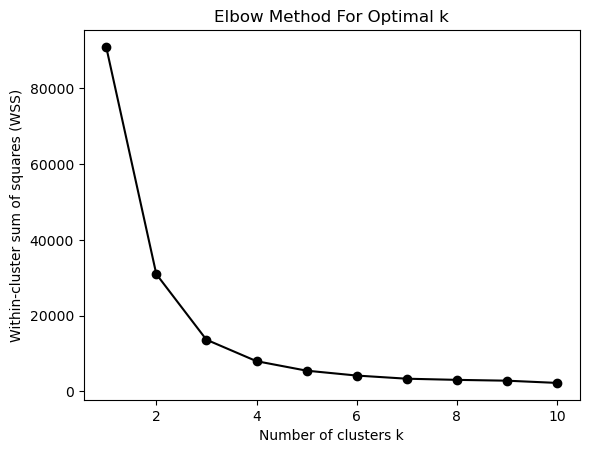

In [14]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
X = df[['FASTING GLUCOSE', 'HDL', 'LDL', 'TOTAL CHOLESTEROL', 'Age','Sex','Comorbidity']].dropna()
wss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    wss.append(kmeans.inertia_)

plt.plot(K_range, wss, 'ko-')
plt.xlabel('Number of clusters k')
plt.ylabel('Within-cluster sum of squares (WSS)')
plt.title('Elbow Method For Optimal k')
plt.show()

In [15]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[['FASTING GLUCOSE', 'HDL', 'LDL', 'TOTAL CHOLESTEROL', 'Age','Sex','Comorbidity']].dropna()

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X)

# Add cluster labels back to DataFrame (align index if needed)
df_clusters = df.loc[X.index].copy()
df_clusters['Cluster'] = clusters
print(df_clusters['Cluster'].value_counts())

Cluster
0    236
1     82
Name: count, dtype: int64


In [16]:
contingency_table = pd.crosstab(df_clusters['Cluster'], df_clusters['State Type Factor'])# Contingency table
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)# Chi-square test
print("Chi-square statistic:", chi2)
print("Degrees of freedom:", dof)
print("P-value:", p)

Chi-square statistic: 0.0346964955144989
Degrees of freedom: 1
P-value: 0.8522330688537005


In [10]:
# mean & median of predictors in each cluster
df_clusters['Sex'] = df_clusters['Sex'].astype('category').cat.codes
df_clusters['Comorbidity'] = df_clusters['Comorbidity'].astype('category').cat.codes
num_cols = ['FASTING GLUCOSE', 'HDL', 'LDL', 'TOTAL CHOLESTEROL', 'Age', 'Sex', 'Comorbidity']
mean_by_cluster = df_clusters.groupby('Cluster')[num_cols].mean()
print("Mean values by cluster:")
print(mean_by_cluster)
median_by_cluster = df_clusters.groupby('Cluster')[num_cols].median()
print("\nMedian values by cluster:")
print(median_by_cluster)

mean_by_cluster.to_excel('mean_values_by_cluster.xlsx', engine='openpyxl')
median_by_cluster.to_excel('median_values_by_cluster.xlsx', engine='openpyxl')

Mean values by cluster:
         FASTING GLUCOSE       HDL       LDL  TOTAL CHOLESTEROL        Age  \
Cluster                                                                      
0               6.103143  1.254481  2.751880           4.879444  38.045113   
1               6.072174  1.293739  3.084522           4.908609  84.586957   
2               5.793237  1.395827  3.040173           4.856115  56.431655   

              Sex  Comorbidity  
Cluster                         
0        0.518797     0.924812  
1        0.739130     1.000000  
2        0.345324     0.992806  

Median values by cluster:
         FASTING GLUCOSE    HDL    LDL  TOTAL CHOLESTEROL   Age  Sex  \
Cluster                                                                
0                   5.28  1.218  2.742              4.806  39.0  1.0   
1                   6.18  1.294  3.102              4.932  87.0  1.0   
2                   5.34  1.360  3.150              4.866  55.0  0.0   

         Comorbidity  
Cluster  

In [11]:
# visulization the confusion matrix
comparison_df = df.loc[X.index].copy()
comparison_df['Cluster'] = clusters

ct = pd.crosstab(comparison_df['Cluster'], comparison_df['State Type Factor'])
print(ct)
ct.to_excel("cluster_vs_state_confusion_matrix.xlsx", engine="openpyxl")

State Type Factor  Manic  Unspecified
Cluster                              
0                     71           62
1                     37            9
2                     54           85


In [37]:
# logistic regression
X = df[['FASTING GLUCOSE', 'HDL', 'LDL', 'TOTAL CHOLESTEROL', 'Age', 'Sex', 'Comorbidity']]
y = (df['State Type Factor'] == 'Manic').astype(int)
X['Sex'] = X['Sex'].astype('category').cat.codes
X['Comorbidity'] = X['Comorbidity'].astype('category').cat.codes

import statsmodels.api as sm
X = sm.add_constant(X)
model = sm.Logit(y, X)
result = model.fit()
print(result.summary())
summary_table = result.summary2().tables[1]
summary_table.to_excel('logit_regression_results.xlsx', engine='openpyxl')

Optimization terminated successfully.
         Current function value: 0.655346
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:      State Type Factor   No. Observations:                  318
Model:                          Logit   Df Residuals:                      310
Method:                           MLE   Df Model:                            7
Date:                Wed, 23 Jul 2025   Pseudo R-squ.:                 0.05429
Time:                        15:38:52   Log-Likelihood:                -208.40
converged:                       True   LL-Null:                       -220.36
Covariance Type:            nonrobust   LLR p-value:                  0.001173
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 1.1026      1.268      0.869      0.385      -1.383       3.588
FASTING 